# Concordances

Using polars_corpus to do basic corpus searching

In [1]:
import polars as pl
import polars.selectors as cs
import polars_corpus as plc
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
bnc = pl.read_parquet("bnc.parquet")

In [3]:
bnc.head(10)

token,c5,pos,mode,text_type,fileid,sent_tag,hw
str,str,str,cat,cat,cat,str,str
"""ACET""","""NP0""","""SUBST""","""written""","""OTHERPUB""","""A02""","""B""","""acet"""
"""AIDS""","""NN1""","""SUBST""","""written""","""OTHERPUB""","""A02""","""I""","""aids"""
"""CARE""","""NN1-VVB""","""SUBST""","""written""","""OTHERPUB""","""A02""","""I""","""care"""
"""EDUCATION""","""NN1""","""SUBST""","""written""","""OTHERPUB""","""A02""","""I""","""education"""
"""AND""","""CJC""","""CONJ""","""written""","""OTHERPUB""","""A02""","""I""","""and"""
"""TRAINING""","""NN1""","""SUBST""","""written""","""OTHERPUB""","""A02""","""I""","""training"""
"""ANNUAL""","""AJ0""","""ADJ""","""written""","""OTHERPUB""","""A02""","""B""","""annual"""
"""REVIEW""","""NN1""","""SUBST""","""written""","""OTHERPUB""","""A02""","""I""","""review"""
"""1990/91""","""CRD""","""ADJ""","""written""","""OTHERPUB""","""A02""","""I""","""1990/91"""


Brezina pg. 26

In [4]:
the = bnc.filter(mode='spoken') \
    .group_by('fileid') \
    .agg((pl.col('hw').len().alias('n'),
         (pl.col('hw')=='the').sum().alias('the'),
         (pl.col('hw')=='i').sum().alias('i'),
         (pl.col('hw')=='you').sum().alias('you'))) \
    .select('fileid',
            (cs.numeric().exclude('n') / pl.col('n') * 10000)) \
    .sort(by='fileid')

the.head(10)

fileid,the,i,you
cat,f64,f64,f64
"""D8Y""",351.247854,150.534795,143.932391
"""D90""",418.747599,257.395313,142.14368
"""D91""",466.304523,371.645243,173.721293
"""D92""",551.431601,466.59597,254.506893
"""DCH""",277.288276,273.660205,137.866694
"""DCJ""",579.399142,89.138329,64.377682
"""DCK""",445.04383,175.320297,101.146325
"""D94""",91.743119,581.039755,183.486239
"""D95""",404.672276,248.007086,177.701506


<Axes: xlabel='Count', ylabel='the'>

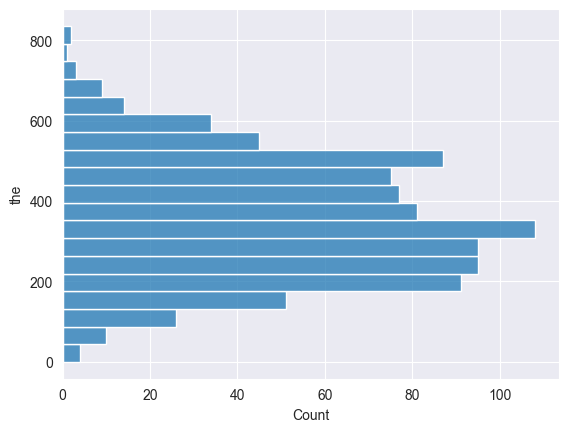

In [11]:
sns.histplot(the.to_pandas(), y='the')

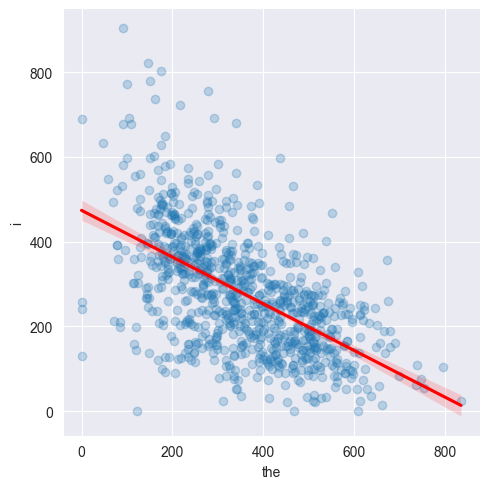

In [12]:
sns.lmplot(the.to_pandas(), x='the', y='i', scatter_kws={'alpha':0.25}, line_kws={'color':'red'})

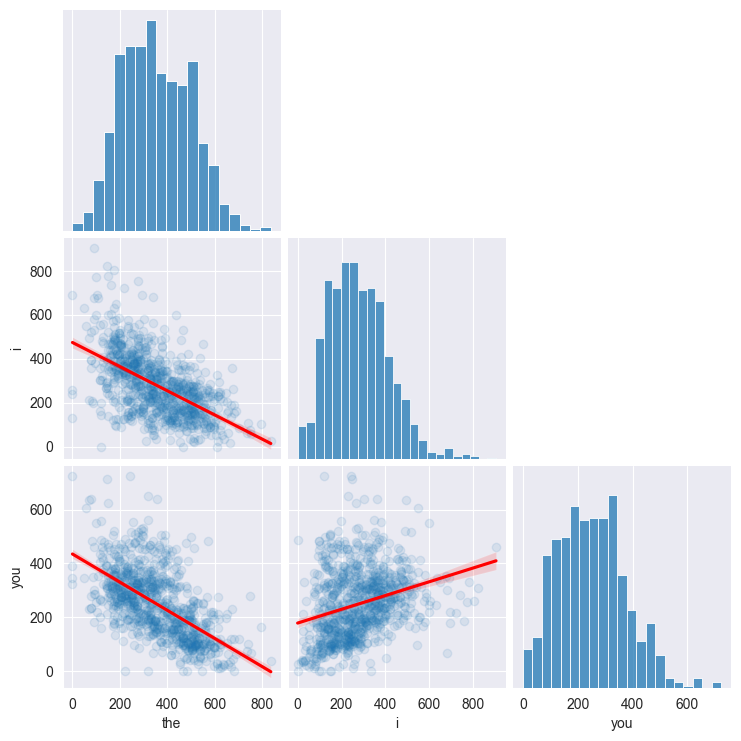

In [13]:
sns.pairplot(the.to_pandas(), vars=['the','i','you'], kind='reg', corner=True, plot_kws={'scatter_kws':{'alpha':0.1}, 'line_kws':{'color':'red'}})

In [8]:
hits = bnc.filter(pl.col("hw").is_in(["very", "really", "rather", "quite"]),
                  pl.col("c5") == 'AV0')
counts = hits.group_by("hw", "text_type") \
    .agg(pl.len().alias('count')) \
    .with_columns(
    (pl.col('count') / pl.col('count').sum().over('text_type') * 100).alias('pct')
)
counts

hw,text_type,count,pct
str,cat,u32,f64
"""really""","""UNPUB""",1110,14.428701
"""rather""","""NEWS""",2513,17.514636
"""very""","""UNPUB""",4489,58.351748
"""really""","""OTHERSP""",8684,23.862387
"""rather""","""ACPROSE""",10111,35.007963
…,…,…,…
"""really""","""FICTION""",10551,22.804098
"""very""","""NEWS""",7406,51.61695
"""quite""","""NEWS""",1929,13.444382


In [5]:
chart = counts.plot.bar(x="pct", y="text_type", color="hw").properties(height=500,width=800)
chart.encoding.y.title = "Text type"
chart

alt.Chart(...)

In [22]:
bnc.filter(pl.col('tok')=='really').group_by('c5').len()


c5,len
str,u32
"""UNC""",1
"""AV0""",44325


In [6]:
r = plc.Concordance(bnc, '[tok="very|really"]')

In [7]:
hits = plc.with_spans(bnc, r.spans)  # .filter(pl.col('spans')!='O')

In [8]:
hits.filter(pl.col("spans") != "O")

tok,c5,pos,mode,text_type,fileid,sentid,hw,spans
str,str,str,str,str,str,str,str,str
"""very""","""AV0""","""ADV""","""written""","""NONAC""","""A00""","""A00:25""","""very""","""B"""
"""very""","""AV0""","""ADV""","""written""","""NONAC""","""A00""","""A00:41""","""very""","""B"""
"""very""","""AV0""","""ADV""","""written""","""NONAC""","""A00""","""A00:60""","""very""","""B"""
"""very""","""AV0""","""ADV""","""written""","""NONAC""","""A00""","""A00:90""","""very""","""B"""
"""very""","""AV0""","""ADV""","""written""","""NONAC""","""A00""","""A00:182""","""very""","""B"""
…,…,…,…,…,…,…,…,…
"""very""","""AV0""","""ADV""","""spoken""","""CONVRSN""","""KSV""","""KSV:5759""","""very""","""B"""
"""very""","""AV0""","""ADV""","""spoken""","""CONVRSN""","""KSV""","""KSV:5771""","""very""","""B"""
"""really""","""AV0""","""ADV""","""spoken""","""CONVRSN""","""KSV""","""KSV:5783""","""really""","""B"""


In [11]:
ratio = (
    hits.group_by("text_type")
    .agg(
        ((pl.col("tok") == "very").sum() / (pl.col("tok") == "really").sum()).alias(
            "ratio"
        )
    )
    .sort(by="ratio")
)
ratio

text_type,ratio
str,f64
"""CONVRSN""",0.71413
"""FICTION""",2.062849
"""OTHERSP""",2.117939
"""NEWS""",3.091058
"""OTHERPUB""",3.228697
"""UNPUB""",4.162037
"""NONAC""",4.347436
"""ACPROSE""",6.33641
